# COC Base Designer

## Config and Import

In [83]:
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)



NumPy : 2.4.6
Pandas: 3.0.3
Matplotlib: 3.11.0


In [84]:
# backup
# !conda env export --no-builds > environment.yml

# restore
# conda env create -f environment.yml

In [85]:
from pathlib import Path
PATH = Path('C:/xampp/htdocs/coc-base-designer')

path_output = PATH / "output"
path_output.mkdir(parents=True, exist_ok=True)

print(path_output)


C:\xampp\htdocs\coc-base-designer\output


In [86]:
MAP_SIZE = 44

# Matriks kosong
base = np.zeros((MAP_SIZE, MAP_SIZE), dtype=int)

print(base.shape)

buildings = pd.read_csv(
    PATH / "data" / "buildings.csv",
    sep=";"
)
buildings.columns = (
    buildings.columns
    .str.strip()      # hapus spasi depan/belakang
    .str.lower()      # ubah ke huruf kecil
)

(44, 44)


In [87]:
# print(buildings.columns.tolist())
print(buildings.head())
print('--------------------------------')
print(buildings.info())
print('--------------------------------')
print(buildings.columns.tolist())


   id code   name  level   dps  damage_per_hit  hitpoints build_cost  \
0   1   CN  Canon      1   7.0             5.6      300.0        250   
1   1   CN  Canon      2  10.0             8.0      360.0          1   
2   1   CN  Canon      3  13.0            10.4      420.0          4   
3   1   CN  Canon      4  17.0            13.6      500.0         16   
4   1   CN  Canon      5  23.0            18.4      600.0         50   

  build_time  experience  required_th size  min_range  max_range attack_speed  \
0         5s         2.0            1  3x3        9.0        9.0         0.8s   
1        30s         5.0            1  3x3        9.0        9.0         0.8s   
2         2m        10.0            2  3x3        9.0        9.0         0.8s   
3        20m        34.0            3  3x3        9.0        9.0         0.8s   
4        30m        42.0            4  3x3        9.0        9.0         0.8s   

     damage_type target_type  max_count  
0  Single Target      Ground          

## Function


In [98]:
# Fungsi meletakkan bangunan
def place_building(matrix, row, col, width, height, value):
    matrix[row:row+height, col:col+width] = value

# 3x3 to w=3,h=3
def parse_size(size):
    width, height = size.lower().split("x")
    return int(width), int(height)
    
def get_building(code):
    row = buildings.loc[buildings["code"] == code]

    if row.empty:
        raise ValueError(f"Building '{code}' tidak ditemukan.")

    row = row.iloc[0].to_dict()

    width, height = parse_size(row["size"])

    row["width"] = width
    row["height"] = height

    return row

def show_map(base):
    # =============================
    # Plot
    # =============================
    fig, ax = plt.subplots(figsize=(10,10))

    ax.imshow(
        base,
        cmap="tab20",
        origin="upper",
        interpolation="none"
    )

    # Grid
    ax.set_xticks(np.arange(-0.5, MAP_SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, MAP_SIZE, 1), minor=True)

    ax.grid(
        which="minor",
        color="lightgray",
        linestyle="-",
        linewidth=0.5
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("Town Hall 2 Layout")

    plt.tight_layout()
    plt.show()

    return fig,ax


## Layout

In [96]:
layout = {
    "townhall_level": 2,
    "buildings": [
        {
            "code": "TH",
            "level": 2,
            "row": 20,
            "col": 20
        },
        {
            "code": "CN",
            "row": 15,
            "col": 15
        },
        {
            "code": "CN",
            "row": 15,
            "col": 25
        },
        {
            "code": "AT",
            "row": 28,
            "col": 20
        }
    ],
    "walls": [
        {"row":19,"col":19},
        {"row":19,"col":20},
        {"row":19,"col":21},
        {"row":19,"col":22},
        {"row":19,"col":23},
        {"row":19,"col":24},

        {"row":24,"col":19},
        {"row":24,"col":20},
        {"row":24,"col":21},
        {"row":24,"col":22},
        {"row":24,"col":23},
        {"row":24,"col":24},

        {"row":20,"col":19},
        {"row":21,"col":19},
        {"row":22,"col":19},
        {"row":23,"col":19},

        {"row":20,"col":24},
        {"row":21,"col":24},
        {"row":22,"col":24},
        {"row":23,"col":24},

        {"row":18,"col":21},
        {"row":18,"col":22},
        {"row":25,"col":21},
        {"row":25,"col":22},
        {"row":25,"col":23}
    ]
}

## Show

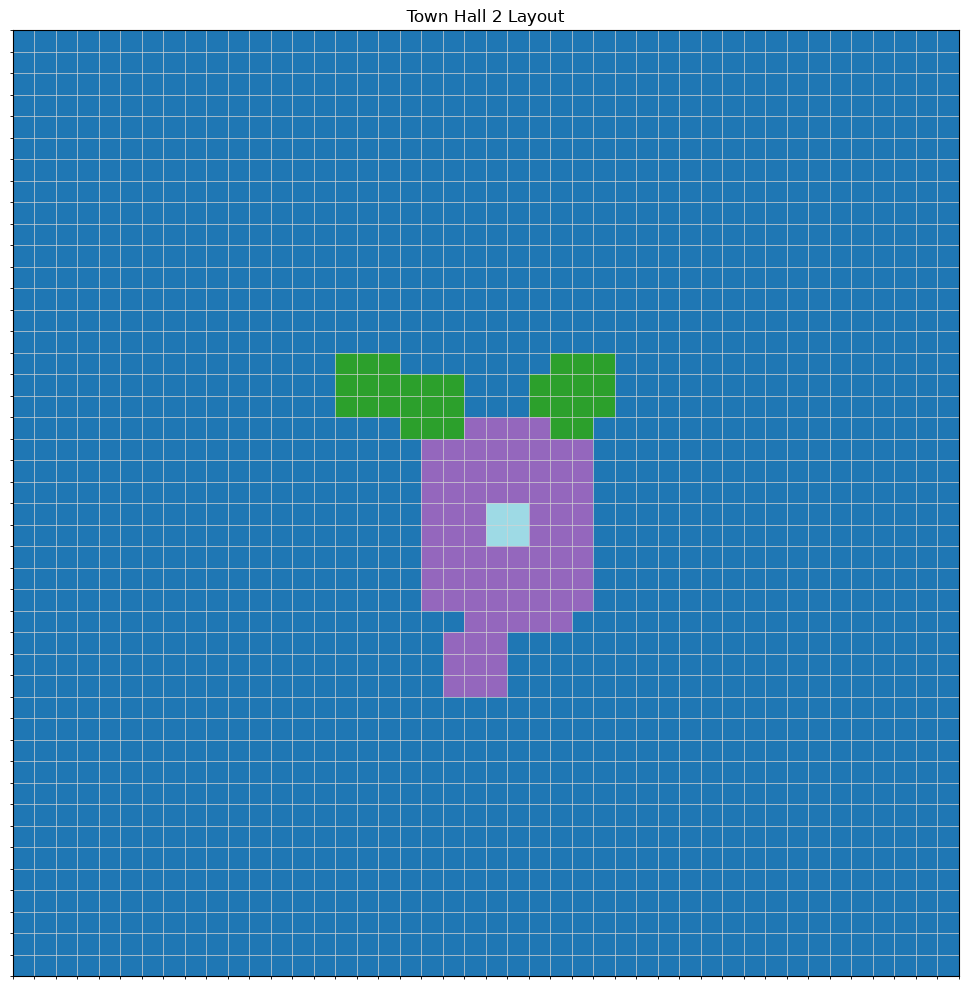

In [99]:
for b in layout["buildings"]:
    building = get_building(b["code"])

    place_building(
        base,
        b["row"],
        b["col"],
        building["width"],
        building["height"],
        building["id"]
    )

wall = get_building(b["code"])

for w in layout["walls"]:
    place_building(
        base,
        w["row"],
        w["col"],
        wall["width"],
        wall["height"],
        wall["id"]
    )



fig = show_map(base)

## Save Output

In [ ]:
def save_map(fig,filename):
    try:
        save_path = path_output / filename
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Map berhasil disimpan di: {save_path.resolve()}")
    except Exception as e:
        print(f"Gagal menyimpan map: {e}")

save_map(fig, "th2.png")

Map berhasil disimpan di: C:\xampp\htdocs\coc-base-designer\output\th2.png
